# Actividad 3 — Ciencia de Datos
## Regresión lineal simple aplicada al Mundial de Fútbol

### Objetivo
Desarrollar un modelo de regresión lineal simple para predecir los goles anotados por una selección en un partido de la Copa Mundial, utilizando como variable independiente su promedio histórico de goles anotados en partidos previos del mismo torneo.

### Fuente de datos
Dataset: International football results from 1872 to 2017  
Archivo utilizado: `results.csv`  
Ruta local: `./data/results.csv`

### Enfoque del análisis
La variable dependiente será la cantidad de goles anotados por un equipo en un partido del Mundial.  
La variable independiente será el promedio histórico de goles anotados por ese mismo equipo en sus partidos previos de la Copa Mundial.

### Justificación del enfoque
Este enfoque permite construir un modelo de regresión lineal simple con una relación interpretable: equipos con mejor rendimiento ofensivo histórico en el Mundial podrían tender a anotar más goles en partidos posteriores.

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from scipy.stats import pearsonr
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)

## 1. Carga de datos
En esta sección se carga el archivo `results.csv` desde la carpeta local `./data` para comenzar con la revisión y limpieza de los datos.

In [2]:
file_path = "./data/results.csv"
results = pd.read_csv(file_path)

print("Shape:", results.shape)
results.head()

Shape: (49287, 9)


,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral
0,1872-11-30,Scotland,England,0.0,0.0,Friendly,Glasgow,Scotland,False
1,1873-03-08,England,Scotland,4.0,2.0,Friendly,London,England,False
2,1874-03-07,Scotland,England,2.0,1.0,Friendly,Glasgow,Scotland,False
3,1875-03-06,England,Scotland,2.0,2.0,Friendly,London,England,False
4,1876-03-04,Scotland,England,3.0,0.0,Friendly,Glasgow,Scotland,False


## 2. Inspección inicial del dataset
Se revisan los nombres de columnas, tipos de datos y una muestra general para comprender la estructura del archivo.

In [3]:
# Columns
results.columns.tolist()

# Dataset details
results.info()

# Sample
results.sample(5, random_state=42)

<class 'pandas.DataFrame'>
RangeIndex: 49287 entries, 0 to 49286
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   date        49287 non-null  str    
 1   home_team   49287 non-null  str    
 2   away_team   49287 non-null  str    
 3   home_score  49215 non-null  float64
 4   away_score  49215 non-null  float64
 5   tournament  49287 non-null  str    
 6   city        49287 non-null  str    
 7   country     49287 non-null  str    
 8   neutral     49287 non-null  bool   
dtypes: bool(1), float64(2), str(6)
memory usage: 3.1 MB


,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral
18998,1993-05-07,Lebanon,India,2.0,2.0,FIFA World Cup qualification,Beirut,Lebanon,False
22400,1997-10-12,Thailand,Cambodia,4.0,0.0,Southeast Asian Games,Jakarta,Indonesia,True
12591,1980-12-28,Hong Kong,North Korea,2.0,2.0,FIFA World Cup qualification,So Kon Po,Hong Kong,False
45045,2022-03-29,Poland,Sweden,2.0,0.0,FIFA World Cup qualification,Chorzów,Poland,False
49024,2025-12-24,Ivory Coast,Mozambique,1.0,0.0,African Cup of Nations,Marrakesh,Morocco,True


## 3. Limpieza y preparación de los datos
Para asegurar la calidad del análisis, se revisarán:
- valores faltantes,
- registros duplicados,
- tipos de datos,
- estandarización básica de columnas de texto.

Después se filtrarán únicamente los partidos correspondientes a la Copa Mundial de la FIFA.

In [4]:
missing_values = results.isna().sum().sort_values(ascending=False)
duplicates_count = results.duplicated().sum()

print("Missing values by column:")
print(missing_values)
print("\nDuplicated rows:", duplicates_count)

Missing values by column:
home_score    72
away_score    72
date           0
home_team      0
away_team      0
tournament     0
city           0
country        0
neutral        0
dtype: int64

Duplicated rows: 0


In [5]:
results_clean = results.copy()

text_columns = ["home_team", "away_team", "tournament", "city", "country"]
for col in text_columns:
    results_clean[col] = results_clean[col].astype(str).str.strip()

results_clean["date"] = pd.to_datetime(results_clean["date"], errors="coerce")
results_clean["home_score"] = pd.to_numeric(
    results_clean["home_score"], errors="coerce"
)
results_clean["away_score"] = pd.to_numeric(
    results_clean["away_score"], errors="coerce"
)

results_clean = results_clean.drop_duplicates()

results_clean = results_clean.dropna(
    subset=[
        "date",
        "home_team",
        "away_team",
        "home_score",
        "away_score",
        "tournament",
    ]
)

print("Shape after basic cleaning:", results_clean.shape)
results_clean.head()

Shape after basic cleaning: (49215, 9)


,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral
0,1872-11-30,Scotland,England,0.0,0.0,Friendly,Glasgow,Scotland,False
1,1873-03-08,England,Scotland,4.0,2.0,Friendly,London,England,False
2,1874-03-07,Scotland,England,2.0,1.0,Friendly,Glasgow,Scotland,False
3,1875-03-06,England,Scotland,2.0,2.0,Friendly,London,England,False
4,1876-03-04,Scotland,England,3.0,0.0,Friendly,Glasgow,Scotland,False


In [6]:
world_cup = results_clean[
    results_clean["tournament"] == "FIFA World Cup"
].copy()

print("World Cup matches:", world_cup.shape[0])
world_cup.head()

World Cup matches: 964


,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral
1486,1930-07-13,Belgium,United States,0.0,3.0,FIFA World Cup,Montevideo,Uruguay,True
1487,1930-07-13,France,Mexico,4.0,1.0,FIFA World Cup,Montevideo,Uruguay,True
1488,1930-07-14,Brazil,Yugoslavia,1.0,2.0,FIFA World Cup,Montevideo,Uruguay,True
1489,1930-07-14,Peru,Romania,1.0,3.0,FIFA World Cup,Montevideo,Uruguay,True
1490,1930-07-15,Argentina,France,1.0,0.0,FIFA World Cup,Montevideo,Uruguay,True


## 4. Construcción de la unidad de análisis
El archivo original tiene un registro por partido, con información separada en:
- equipo local,
- equipo visitante,
- goles del local,
- goles del visitante.

Para este análisis se necesita una tabla a nivel **equipo-partido**, es decir, dos registros por encuentro:
- uno para el equipo local,
- uno para el equipo visitante.

Esto permitirá calcular, para cada selección, su promedio histórico de goles anotados antes de cada partido.

In [7]:
world_cup = world_cup.sort_values("date").reset_index(drop=True)
world_cup["match_id"] = world_cup.index

home_matches = world_cup[
    [
        "match_id",
        "date",
        "home_team",
        "away_team",
        "home_score",
        "away_score",
        "neutral",
    ]
].copy()

home_matches.columns = [
    "match_id",
    "date",
    "team",
    "opponent",
    "goals_scored",
    "goals_conceded",
    "neutral",
]
home_matches["match_side"] = "home"

away_matches = world_cup[
    [
        "match_id",
        "date",
        "away_team",
        "home_team",
        "away_score",
        "home_score",
        "neutral",
    ]
].copy()

away_matches.columns = [
    "match_id",
    "date",
    "team",
    "opponent",
    "goals_scored",
    "goals_conceded",
    "neutral",
]
away_matches["match_side"] = "away"

team_matches = pd.concat([home_matches, away_matches], ignore_index=True)

team_matches = team_matches.sort_values(
    ["team", "date", "match_id"]
).reset_index(drop=True)

print("Team-match dataset shape:", team_matches.shape)
team_matches.head(10)

Team-match dataset shape: (1928, 8)


,match_id,date,team,opponent,goals_scored,goals_conceded,neutral,match_side
0,315,1982-06-16,Algeria,Germany,2.0,1.0,True,away
1,331,1982-06-21,Algeria,Austria,0.0,2.0,True,home
2,338,1982-06-24,Algeria,Chile,3.0,2.0,True,home
3,366,1986-06-03,Algeria,Northern Ireland,1.0,1.0,True,home
4,376,1986-06-06,Algeria,Brazil,0.0,1.0,True,away
5,392,1986-06-12,Algeria,Spain,0.0,3.0,True,home
6,713,2010-06-13,Algeria,Slovenia,0.0,1.0,True,home
7,728,2010-06-18,Algeria,England,0.0,0.0,True,away
8,747,2010-06-23,Algeria,United States,0.0,1.0,True,away
9,786,2014-06-17,Algeria,Belgium,1.0,2.0,True,away


## 5. Creación de la variable independiente
La variable independiente será:

**`avg_goals_scored_before_match`**  
Promedio histórico de goles anotados por cada selección en sus partidos previos del Mundial.

Para calcularla:
1. se ordenan los partidos por selección y fecha,
2. se cuentan los partidos previos de cada equipo,
3. se suman los goles anotados antes del partido actual,
4. se divide la suma previa entre el número de partidos previos.

In [8]:
team_matches["previous_matches"] = team_matches.groupby("team").cumcount()

team_matches["previous_goals_sum"] = (
    team_matches.groupby("team")["goals_scored"].cumsum()
    - team_matches["goals_scored"]
)

team_matches["avg_goals_scored_before_match"] = (
    team_matches["previous_goals_sum"] / team_matches["previous_matches"]
)

team_matches.head(15)

,match_id,date,team,opponent,goals_scored,goals_conceded,neutral,match_side,previous_matches,previous_goals_sum,avg_goals_scored_before_match
0,315,1982-06-16,Algeria,Germany,2.0,1.0,True,away,0,0.0,NaN
1,331,1982-06-21,Algeria,Austria,0.0,2.0,True,home,1,2.0,2.000000
2,338,1982-06-24,Algeria,Chile,3.0,2.0,True,home,2,2.0,1.000000
3,366,1986-06-03,Algeria,Northern Ireland,1.0,1.0,True,home,3,5.0,1.666667
4,376,1986-06-06,Algeria,Brazil,0.0,1.0,True,away,4,6.0,1.500000
5,392,1986-06-12,Algeria,Spain,0.0,3.0,True,home,5,6.0,1.200000
6,713,2010-06-13,Algeria,Slovenia,0.0,1.0,True,home,6,6.0,1.000000
7,728,2010-06-18,Algeria,England,0.0,0.0,True,away,7,6.0,0.857143
8,747,2010-06-23,Algeria,United States,0.0,1.0,True,away,8,6.0,0.750000
9,786,2014-06-17,Algeria,Belgium,1.0,2.0,True,away,9,6.0,0.666667


In [9]:
model_df = team_matches[team_matches["previous_matches"] > 0].copy()

model_df = model_df.dropna(
    subset=["avg_goals_scored_before_match", "goals_scored"]
)

model_df = model_df.reset_index(drop=True)

print("Final dataset for modeling:", model_df.shape)
model_df.head(10)

Final dataset for modeling: (1846, 11)


,match_id,date,team,opponent,goals_scored,goals_conceded,neutral,match_side,previous_matches,previous_goals_sum,avg_goals_scored_before_match
0,331,1982-06-21,Algeria,Austria,0.0,2.0,True,home,1,2.0,2.000000
1,338,1982-06-24,Algeria,Chile,3.0,2.0,True,home,2,2.0,1.000000
2,366,1986-06-03,Algeria,Northern Ireland,1.0,1.0,True,home,3,5.0,1.666667
3,376,1986-06-06,Algeria,Brazil,0.0,1.0,True,away,4,6.0,1.500000
4,392,1986-06-12,Algeria,Spain,0.0,3.0,True,home,5,6.0,1.200000
5,713,2010-06-13,Algeria,Slovenia,0.0,1.0,True,home,6,6.0,1.000000
6,728,2010-06-18,Algeria,England,0.0,0.0,True,away,7,6.0,0.857143
7,747,2010-06-23,Algeria,United States,0.0,1.0,True,away,8,6.0,0.750000
8,786,2014-06-17,Algeria,Belgium,1.0,2.0,True,away,9,6.0,0.666667
9,802,2014-06-22,Algeria,South Korea,4.0,2.0,True,away,10,7.0,0.700000


In [10]:
print("Missing values in modeling dataset:")
print(model_df.isna().sum())

print("\nDuplicated rows in modeling dataset:", model_df.duplicated().sum())

Missing values in modeling dataset:
match_id                         0
date                             0
team                             0
opponent                         0
goals_scored                     0
goals_conceded                   0
neutral                          0
match_side                       0
previous_matches                 0
previous_goals_sum               0
avg_goals_scored_before_match    0
dtype: int64

Duplicated rows in modeling dataset: 0


## 6. Análisis exploratorio
Se analizará la relación entre:
- `avg_goals_scored_before_match` (variable independiente)
- `goals_scored` (variable dependiente)

Primero se calculará la correlación de Pearson y después se visualizará la relación con una gráfica de dispersión.

In [11]:
pearson_r, pearson_p = pearsonr(
    model_df["avg_goals_scored_before_match"],
    model_df["goals_scored"],
)

print(f"Pearson correlation coefficient: {pearson_r:.4f}")
print(f"P-value: {pearson_p:.4f}")

Pearson correlation coefficient: 0.2324
P-value: 0.0000


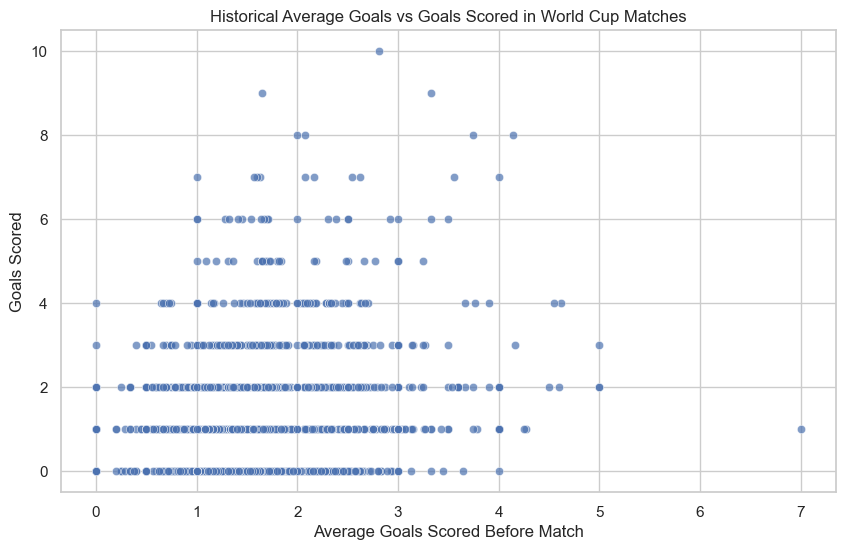

In [12]:
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=model_df,
    x="avg_goals_scored_before_match",
    y="goals_scored",
    alpha=0.7,
)
plt.title("Historical Average Goals vs Goals Scored in World Cup Matches")
plt.xlabel("Average Goals Scored Before Match")
plt.ylabel("Goals Scored")
plt.show()

## 7. Definición de variables y división de datos
Se definirá:
- `X` como la variable independiente,
- `y` como la variable dependiente.

Después, el conjunto de datos se dividirá en:
- 80% para entrenamiento,
- 20% para prueba.

In [13]:
X = model_df[["avg_goals_scored_before_match"]]
y = model_df["goals_scored"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (1476, 1)
X_test shape: (370, 1)
y_train shape: (1476,)
y_test shape: (370,)


## 8. Entrenamiento del modelo de regresión lineal simple
Se entrenará un modelo de regresión lineal simple utilizando el conjunto de entrenamiento.

In [14]:
model = LinearRegression()
model.fit(X_train, y_train)

print(f"Intercept: {model.intercept_:.4f}")
print(f"Coefficient: {model.coef_[0]:.4f}")

Intercept: 0.7221
Coefficient: 0.4393


## 9. Predicción
Con el modelo entrenado, se realizarán predicciones sobre el conjunto de prueba.

In [15]:
y_pred = model.predict(X_test)

predictions_df = pd.DataFrame(
    {
        "Actual": y_test.values,
        "Predicted": y_pred,
    }
)

predictions_df.head(10)

,Actual,Predicted
0,1.0,1.426638
1,1.0,1.051569
2,0.0,1.638493
3,1.0,1.307832
4,1.0,0.722088
5,1.0,1.092031
6,4.0,1.876840
7,1.0,1.381050
8,1.0,1.381050
9,0.0,1.339864


## 10. Evaluación del modelo
Para evaluar el desempeño del modelo se calcularán las siguientes métricas:
- MAE (Mean Absolute Error)
- MSE (Mean Squared Error)
- RMSE (Root Mean Squared Error)
- R² (Coefficient of Determination)

In [16]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"MAE: {mae:.4f}")
print(f"MSE: {mse:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R^2: {r2:.4f}")

MAE: 0.9790
MSE: 1.6307
RMSE: 1.2770
R^2: 0.0475


## 11. Visualización del modelo
Se graficará la línea de regresión para observar visualmente la relación entre la variable independiente y la variable dependiente.

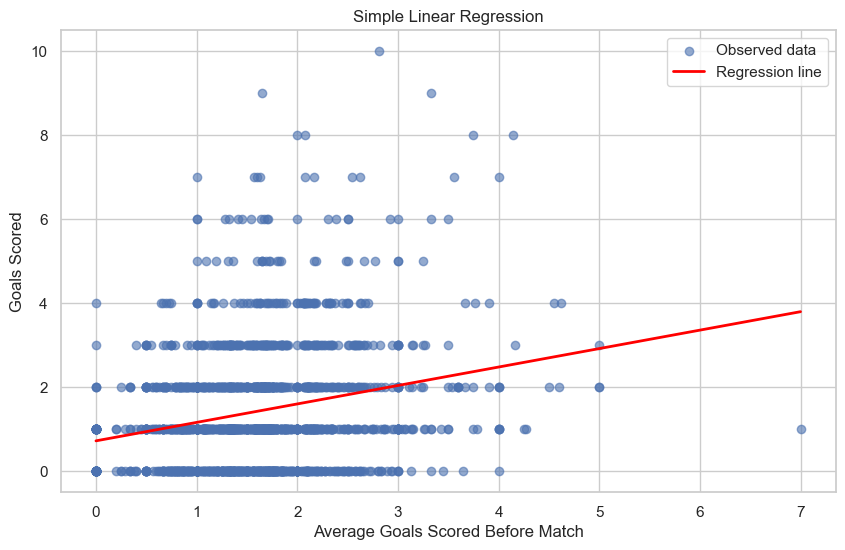

In [17]:
x_line = pd.DataFrame(
    {
        "avg_goals_scored_before_match": np.linspace(
            model_df["avg_goals_scored_before_match"].min(),
            model_df["avg_goals_scored_before_match"].max(),
            100,
        )
    }
)

y_line = model.predict(x_line)

plt.figure(figsize=(10, 6))
plt.scatter(
    model_df["avg_goals_scored_before_match"],
    model_df["goals_scored"],
    alpha=0.6,
    label="Observed data",
)
plt.plot(
    x_line["avg_goals_scored_before_match"],
    y_line,
    color="red",
    linewidth=2,
    label="Regression line",
)
plt.title("Simple Linear Regression")
plt.xlabel("Average Goals Scored Before Match")
plt.ylabel("Goals Scored")
plt.legend()
plt.show()

## 12. Análisis de errores
Se revisará la diferencia entre los valores reales y los predichos mediante los residuales del modelo.

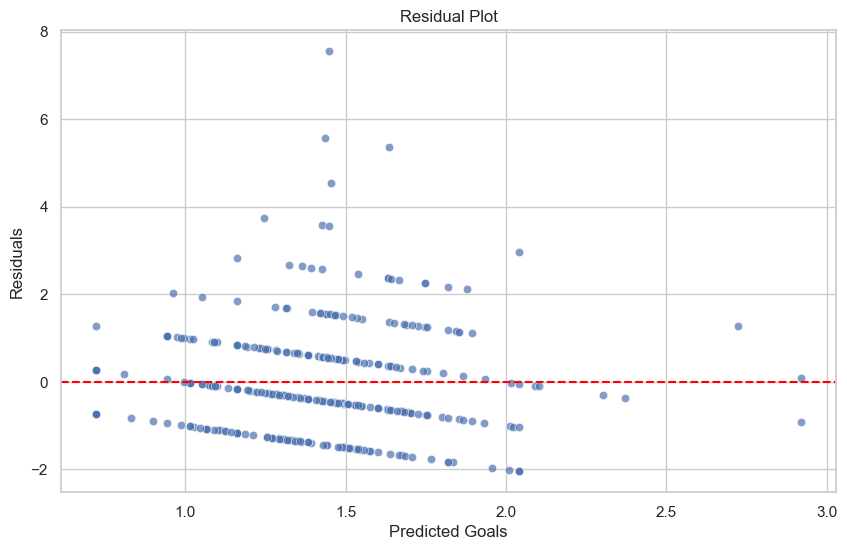

In [18]:
residuals = y_test - y_pred

plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_pred, y=residuals, alpha=0.7)
plt.axhline(0, color="red", linestyle="--")
plt.title("Residual Plot")
plt.xlabel("Predicted Goals")
plt.ylabel("Residuals")
plt.show()

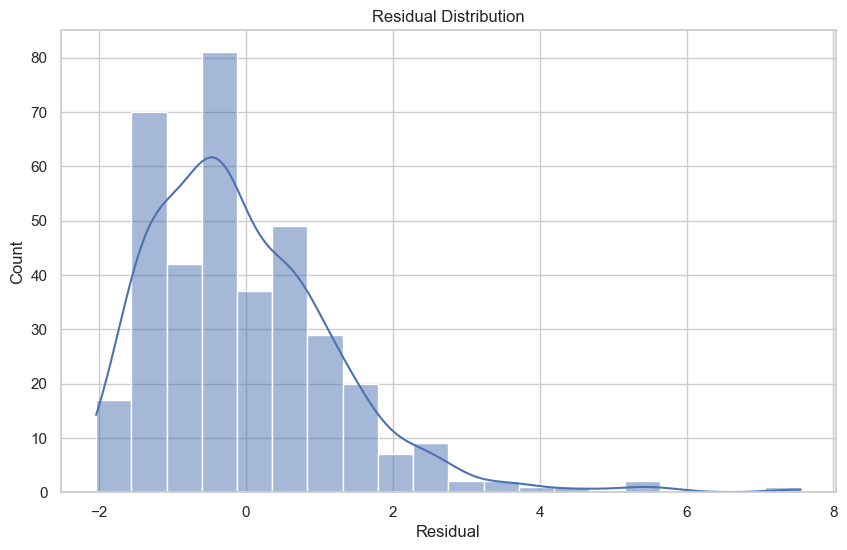

In [19]:
plt.figure(figsize=(10, 6))
sns.histplot(residuals, bins=20, kde=True)
plt.title("Residual Distribution")
plt.xlabel("Residual")
plt.show()

## 13. Interpretación de resultados
En esta sección se resumen los principales hallazgos del modelo:
- la fuerza y dirección de la relación entre las variables,
- el comportamiento del modelo,
- y su utilidad para fines predictivos.

In [20]:
print("Summary of results")
print("-" * 40)
print(f"Pearson r: {pearson_r:.4f}")
print(f"P-value: {pearson_p:.4f}")
print(f"Intercept: {model.intercept_:.4f}")
print(f"Slope: {model.coef_[0]:.4f}")
print(f"MAE: {mae:.4f}")
print(f"MSE: {mse:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R^2: {r2:.4f}")

Summary of results
----------------------------------------
Pearson r: 0.2324
P-value: 0.0000
Intercept: 0.7221
Slope: 0.4393
MAE: 0.9790
MSE: 1.6307
RMSE: 1.2770
R^2: 0.0475


## 14. Conclusión

En este análisis se desarrolló un modelo de regresión lineal simple para predecir los goles anotados por una selección en un partido de la Copa Mundial, utilizando como variable independiente su promedio histórico de goles anotados en partidos previos del mismo torneo.

El análisis exploratorio mostró una correlación de Pearson de **0.2324**, lo que indica una relación positiva, pero débil, entre ambas variables. Además, el valor-p fue de **0.0000**, por lo que esta relación puede considerarse estadísticamente significativa. Esto sugiere que, en general, los equipos con un mayor promedio histórico de goles tienden a anotar más, aunque la intensidad de esta relación es baja.

El modelo entrenado presentó una intersección de **0.7221** y una pendiente de **0.4393**. Esto significa que, según el modelo, por cada incremento de un gol en el promedio histórico previo, la predicción de goles anotados en el siguiente partido aumenta aproximadamente en **0.44** goles. La pendiente positiva confirma la dirección positiva de la relación observada en la correlación.

Sin embargo, las métricas de evaluación muestran que la capacidad predictiva del modelo es limitada. El error absoluto medio (MAE) fue de **0.9790**, lo que indica que, en promedio, las predicciones se desvían cerca de un gol respecto al valor real. El RMSE fue de **1.2770**, lo cual confirma que existen errores considerables en varias predicciones. Además, el coeficiente de determinación **R^2 = 0.0475** indica que el modelo solo explica aproximadamente el **4.75\%** de la variabilidad en los goles anotados, por lo que la mayor parte del comportamiento de la variable dependiente no está siendo explicada por esta única variable.

Visualmente, la nube de puntos mostró una tendencia positiva, pero con una dispersión considerable. La recta de regresión no logra ajustarse con precisión a los datos, y el análisis de residuales muestra una distribución con asimetría y presencia de errores relativamente grandes en algunos casos. Esto sugiere que el modelo no captura completamente la complejidad del fenómeno y que existen partidos atípicos o factores adicionales que influyen de manera importante en la cantidad de goles anotados.

En conclusión, el modelo sí identifica una relación positiva entre el promedio histórico de goles y los goles anotados en un partido del Mundial, pero dicha relación es débil y su poder predictivo es bajo. Por ello, este modelo puede considerarse útil como una aproximación inicial para detectar una tendencia general en el rendimiento ofensivo de las selecciones, pero no es suficiente por sí solo para realizar predicciones precisas o para apoyar decisiones estratégicas complejas.

Como trabajo futuro, sería conveniente incorporar más variables explicativas, como la fortaleza del rival, la fase del torneo, el año del Mundial, la condición de local o neutral, y métricas de rendimiento adicional. Con ello, sería posible construir un modelo más robusto y con mayor capacidad explicativa.